# Визуализация анализа эмодзи-реакций постов

Интерактивный Jupyter notebook для анализа эмодзи-реакций Telegram-постов по делу Ларисы Долины.

**Функции:**
- Топ эмодзи-реакций по каналам (bar chart)
- Тепловые карты эмодзи по месяцам
- Распределение тональности эмодзи (positive/negative/neutral)
- Динамика Emoji Sentiment Index (ESI) по неделям

**Выход:** PNG графики сохраняются в `results/figures/`

In [26]:
import os
from pathlib import Path

# Определяем корневую папку проекта (ищем папку с config/)
current = Path.cwd()
while current != current.parent:
    if (current / "config").exists() and (current / "vizualization").exists():
        project_root = current
        break
    current = current.parent
else:
    # Fallback: если не найдена папка config, идём на 2 уровня выше
    project_root = Path.cwd().parent.parent

os.chdir(project_root)
print(f"✓ Рабочая папка: {project_root.name}/")

✓ Рабочая папка: Algorithm/


In [27]:
import sys
from pathlib import Path
from collections import Counter
from IPython.display import Image, display

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.font_manager as font_manager
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import pandas as pd
import seaborn as sns
import logging

# Добавляем проект в sys.path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

log = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)

In [28]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
from config.settings import (
    CHANNELS,
    EMOJI_SENTIMENT,
    EMOJI_LIKE_DISLIKE,
    EVENTS,
    COLOR_POSITIVE,
    COLOR_NEGATIVE,
    COLOR_NEUTRAL,
    COLOR_STATE,
    COLOR_PUBLIC,
    FIGURE_DPI,
    FIGURES_DIR,
    CLEANED_CSV,
    RESULTS_DIR,
)

from analysis.emoji_analyzer import analyze_corpus

In [30]:
def _register_emoji_fonts() -> list[str]:
    """Регистрирует системные emoji-шрифты и возвращает доступные имена."""
    env_font = os.getenv("EMOJI_FONT_PATH")
    if env_font:
        candidates = [Path(env_font)]
    else:
        candidates = []

    candidates += [
        Path("/System/Library/Fonts/Apple Color Emoji.ttc"),
        Path("/System/Library/Fonts/Supplemental/Apple Color Emoji.ttc"),
        Path("/Library/Fonts/Apple Color Emoji.ttc"),
        Path.home() / "Library/Fonts/Apple Color Emoji.ttc",
        Path("/Library/Fonts/NotoEmoji-Regular.ttf"),
        Path.home() / "Library/Fonts/NotoEmoji-Regular.ttf",
        Path("/Library/Fonts/Symbola.ttf"),
        Path.home() / "Library/Fonts/Symbola.ttf",
        Path("/usr/share/fonts/truetype/noto/NotoEmoji-Regular.ttf"),
        Path("/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf"),
        Path("/usr/share/fonts/truetype/ancient-scripts/Symbola.ttf"),
        Path("C:/Windows/Fonts/seguiemj.ttf"),
    ]

    registered: list[str] = []
    for path in candidates:
        if not path.exists():
            continue
        try:
            font_manager.fontManager.addfont(str(path))
            name = font_manager.FontProperties(fname=str(path)).get_name()
            registered.append(name)
        except Exception as exc:
            log.debug("Не удалось зарегистрировать шрифт %s: %s", path, exc)

    if not registered:
        try:
            font_manager._load_fontmanager(try_read_cache=False)
        except Exception as exc:
            log.debug("Не удалось пересобрать кэш шрифтов: %s", exc)

    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in [
        "Apple Color Emoji",
        "Segoe UI Emoji",
        "Noto Emoji",
        "Noto Color Emoji",
        "Symbola",
    ]:
        if name in available and name not in registered:
            registered.append(name)
    return registered

emoji_fonts = _register_emoji_fonts()
if not emoji_fonts:
    log.warning("Emoji-шрифты не найдены. Установите 'Noto Emoji' или 'Symbola'.")
    emoji_fonts = ["DejaVu Sans"]
else:
    log.info("Emoji-шрифты: %s", ", ".join(emoji_fonts))

# Глобальный стиль matplotlib
plt.rcParams.update({
    "font.family":       emoji_fonts + ["DejaVu Sans", "sans-serif"],
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

sns.set_theme(style="whitegrid", context="notebook", palette="muted")

_CAT_COLOR = {
    "positive": COLOR_POSITIVE,
    "negative": COLOR_NEGATIVE,
    "neutral":  COLOR_NEUTRAL,
    "unknown":  "#bdc3c7",
}

15:38:26  INFO      Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str
15:38:26  INFO      Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
15:38:26  INFO      Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
15:38:26  INFO      Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
15:38:26  INFO      Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
15:38:26  INFO      Failed to extract font properties from /System/

In [31]:
def _save(fig: plt.Figure, name: str) -> Path:
    """Сохраняет фигуру в PNG файл и отображает её в ноутбуке."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    log.info("График сохранён → %s", path)
    plt.close(fig)
    # Отображаем график в ноутбуке
    display(Image(filename=str(path)))
    return path


def _emoji_dict_for(channel_username: str) -> dict[str, str]:
    """Возвращает словарь эмодзи→категория с учётом типа реакций канала."""
    for ch in CHANNELS:
        if ch["username"] == channel_username:
            rtype = ch.get("reaction_type", "none")
            if rtype == "like_dislike":
                return EMOJI_LIKE_DISLIKE
            elif rtype == "emoji_full":
                return EMOJI_SENTIMENT
            return {}
    return EMOJI_SENTIMENT


def _load_corpus() -> pd.DataFrame:
    """Загружает корпус с реакциями (emoji_corpus или predictions)."""
    candidates = [
        RESULTS_DIR / "emoji_corpus.csv",
        RESULTS_DIR / "predictions.csv",
        CLEANED_CSV,
    ]

    for path in candidates:
        if path and path.exists():
            log.info("Загружаем данные: %s", path)
            df = pd.read_csv(path, encoding="utf-8")
            df["reactions_top"]   = df.get("reactions_top", pd.Series(dtype=str)).fillna("")
            df["reactions_total"] = pd.to_numeric(
                df.get("reactions_total", 0), errors="coerce"
            ).fillna(0).astype(int)
            df["date"] = pd.to_datetime(
                df.get("date", pd.Series(dtype=str)), utc=True, errors="coerce"
            )
            return df

    raise FileNotFoundError(
        "Файл данных не найден. Запустите: python main.py --no-collect"
    )


def _count_emojis_for_df(df: pd.DataFrame, channel_username: str) -> Counter:
    """Подсчитывает суммарную частоту каждого эмодзи для канала."""
    ch_df = df[df["channel_username"] == channel_username]
    emoji_counter: Counter = Counter()
    for row_emojis in ch_df["reactions_top"]:
        if isinstance(row_emojis, str) and row_emojis.strip():
            for em in row_emojis.strip().split():
                emoji_counter[em] += 1
    return emoji_counter


def _add_event_markers(ax: plt.Axes, ymin: float = 0, ymax: float = 1) -> None:
    """Добавляет вертикальные линии ключевых событий."""
    for ev in EVENTS:
        x = pd.Timestamp(ev["date"], tz="UTC")
        ax.axvline(x=x, color="#e67e22", linestyle="--", linewidth=0.9, alpha=0.7)
        ax.text(x, ymax * 0.96, ev["short"],
                rotation=90, fontsize=6.5, color="#e67e22",
                alpha=0.85, va="top", ha="right")

## Загрузка данных

In [32]:
df = _load_corpus()
print(f"✓ Загружено {len(df)} записей с эмодзи-реакциями")
print(f"  Каналы: {df['channel_username'].nunique()}")
print(f"  Период: {df['date'].min().date()} — {df['date'].max().date()}")

15:38:26  INFO      Загружаем данные: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/predictions.csv


✓ Загружено 523 записей с эмодзи-реакциями
  Каналы: 10
  Период: 2025-03-03 — 2025-12-30


## 1. Топ эмодзи-реакций по каналам

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_1_frequency_by_channel.png


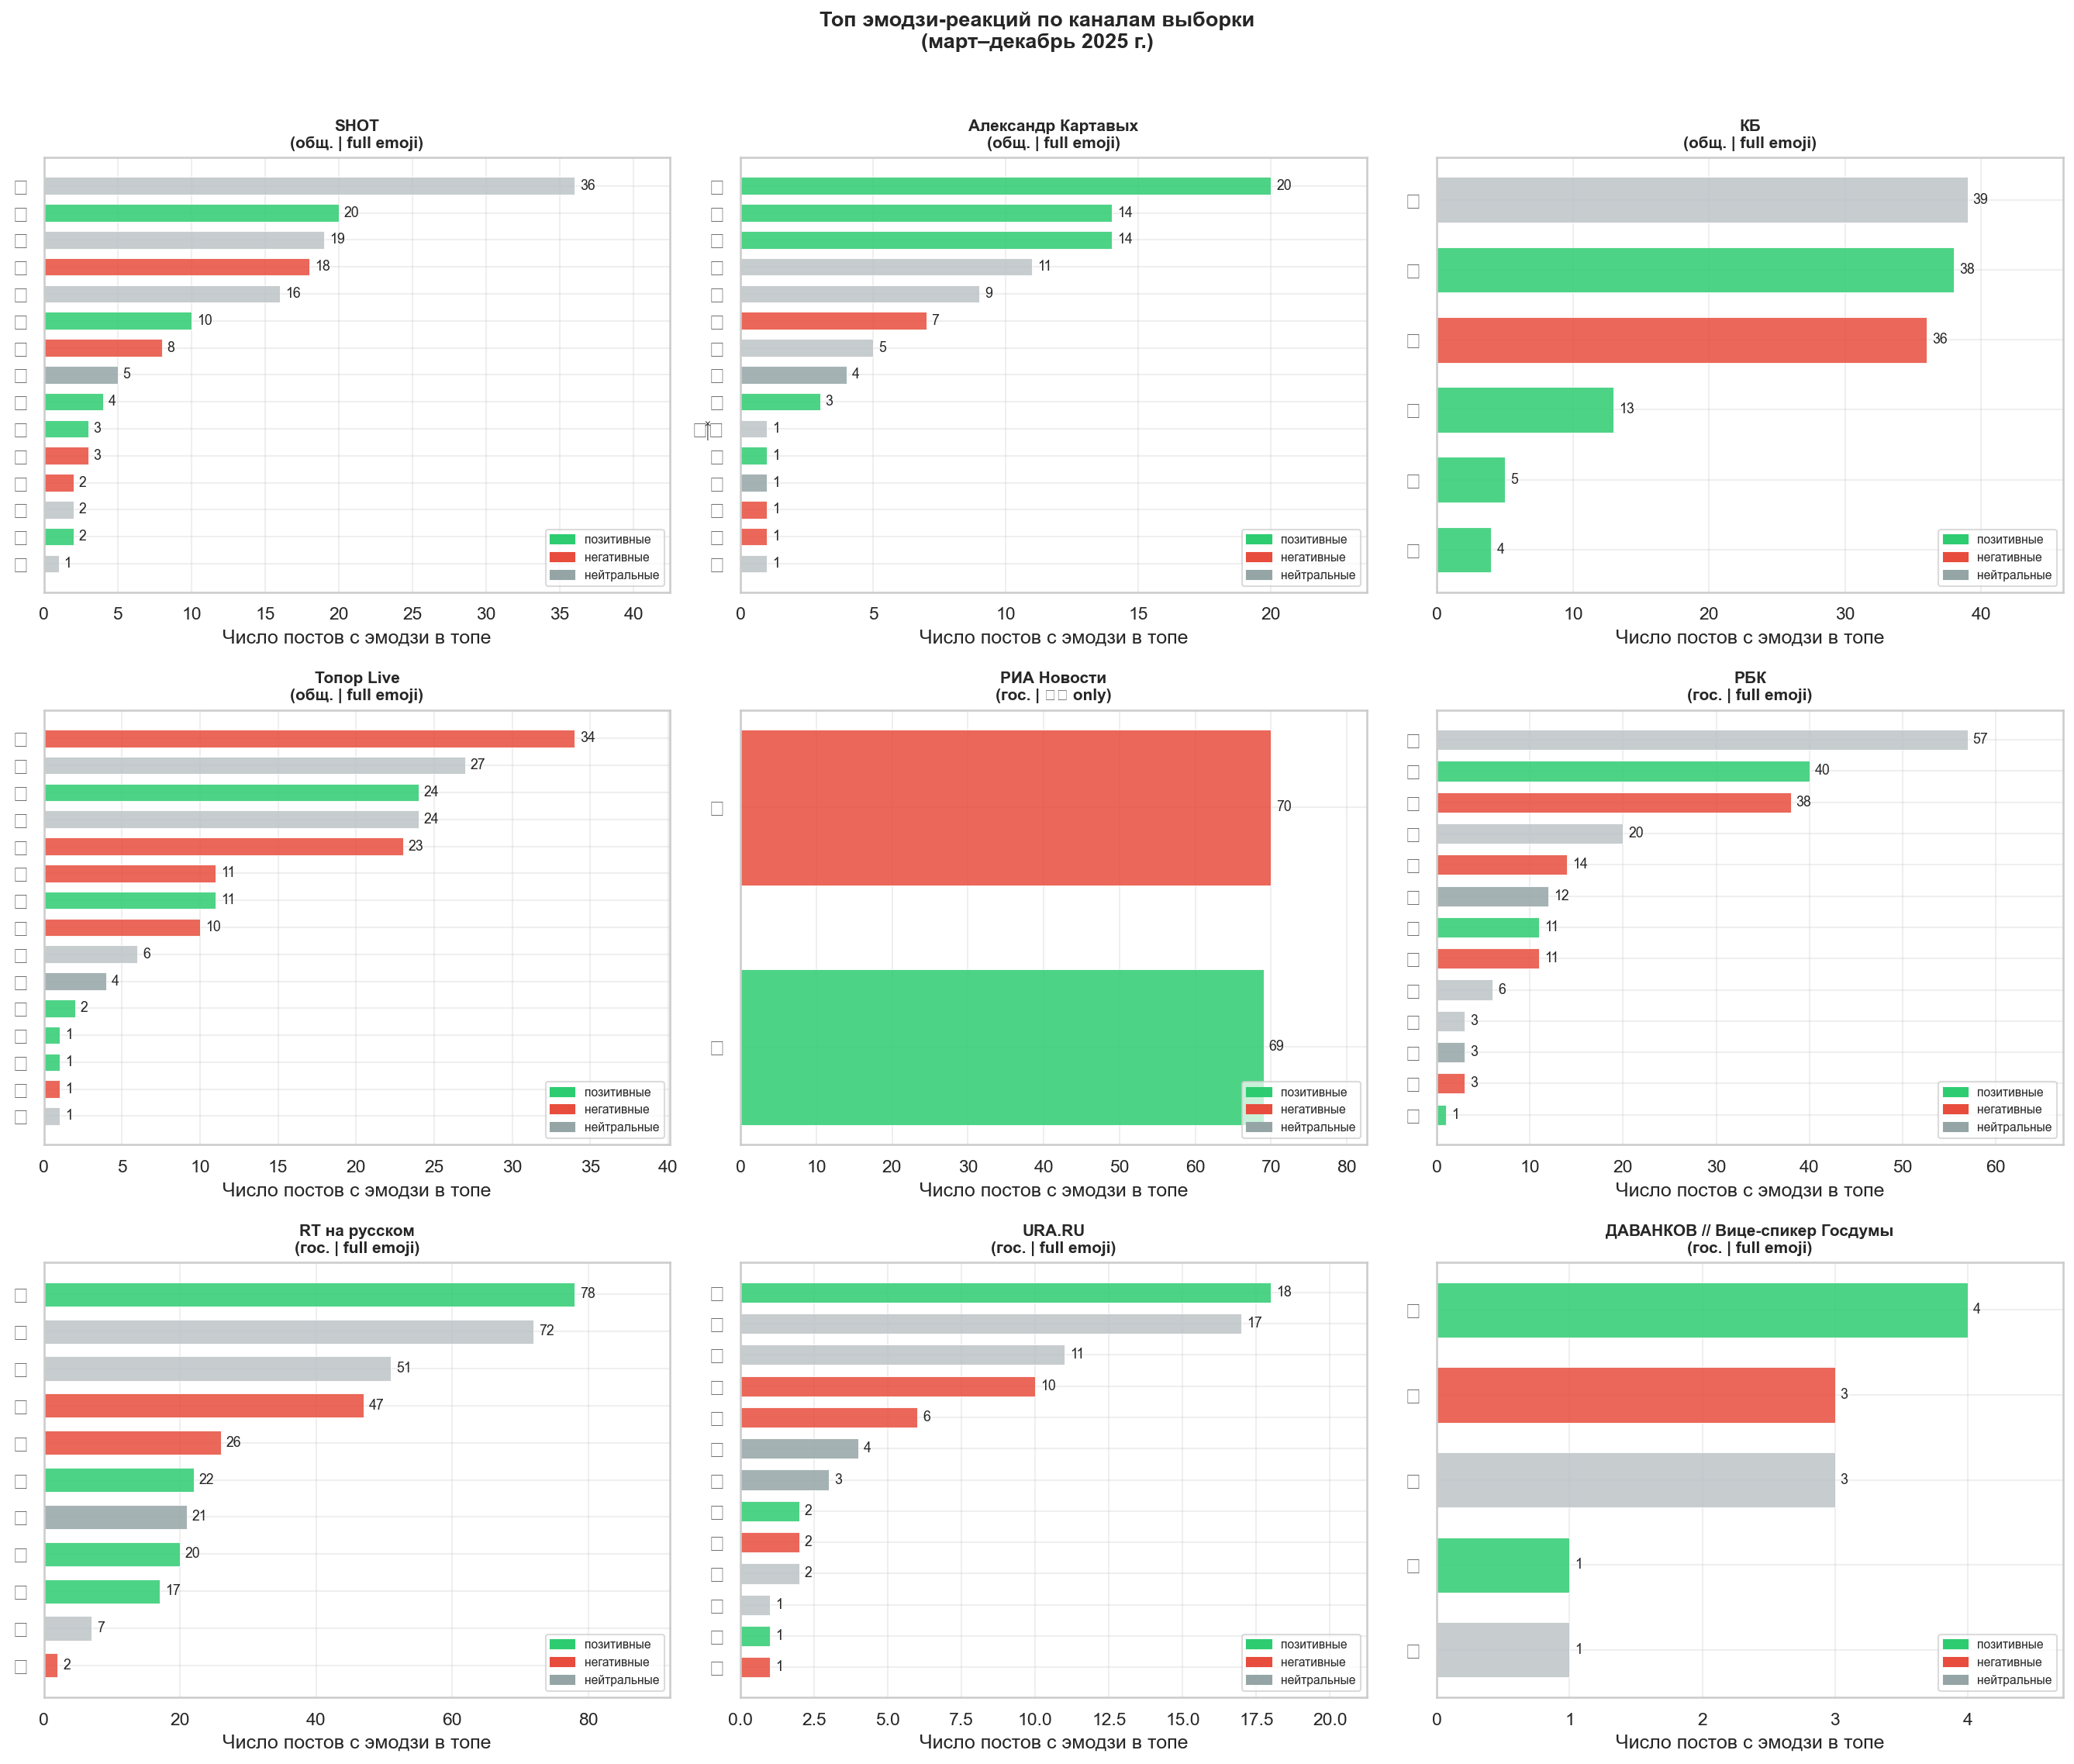

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_1_frequency_by_channel.png')

In [33]:
def plot_emoji_frequency_by_channel(df: pd.DataFrame, channels: list[str] | None = None, top_n: int = 15) -> Path:
    """Горизонтальный bar chart топ-N эмодзи для каждого канала."""
    if channels is None:
        channels = [ch["username"] for ch in CHANNELS if ch.get("reaction_type") != "none"]

    channel_counters: dict[str, Counter] = {}
    for username in channels:
        cnt = _count_emojis_for_df(df, username)
        if cnt:
            channel_counters[username] = cnt

    if not channel_counters:
        log.warning("Нет данных о реакциях для выбранных каналов.")
        return FIGURES_DIR / "no_data.txt"

    n_channels = len(channel_counters)
    cols = min(3, n_channels)
    rows = (n_channels + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5), squeeze=False)
    axes_flat = axes.flatten()

    for ax_idx, (username, counter) in enumerate(channel_counters.items()):
        ax = axes_flat[ax_idx]
        ch_meta = next((c for c in CHANNELS if c["username"] == username), {})
        label = ch_meta.get("label", username)
        rtype = ch_meta.get("reaction_type", "emoji_full")
        emoji_dict = _emoji_dict_for(username)

        top_items = counter.most_common(top_n)
        if not top_items:
            ax.set_visible(False)
            continue

        emojis = [item[0] for item in top_items]
        counts = [item[1] for item in top_items]
        colors = [_CAT_COLOR.get(emoji_dict.get(e, "unknown"), "#bdc3c7") for e in emojis]

        y_pos = range(len(emojis))
        bars = ax.barh(list(y_pos), counts, color=colors, alpha=0.85, height=0.65, edgecolor="white", linewidth=0.5)

        for bar, count in zip(bars, counts):
            ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
                   str(count), va="center", fontsize=8.5)

        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(emojis, fontsize=14)
        ax.invert_yaxis()

        orient_label = "гос." if ch_meta.get("orientation") == "state" else "общ."
        rtype_label = "👍👎 only" if rtype == "like_dislike" else "full emoji"
        ax.set_title(f"{label}\n({orient_label} | {rtype_label})", fontsize=10, fontweight="bold")
        ax.set_xlabel("Число постов с эмодзи в топе")
        ax.set_xlim(0, max(counts) * 1.18)

        legend_handles = [
            Patch(color=COLOR_POSITIVE, label="позитивные"),
            Patch(color=COLOR_NEGATIVE, label="негативные"),
            Patch(color=COLOR_NEUTRAL, label="нейтральные"),
        ]
        ax.legend(handles=legend_handles, loc="lower right", fontsize=7.5, framealpha=0.7)

    for i in range(len(channel_counters), len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle("Топ эмодзи-реакций по каналам выборки\n(март–декабрь 2025 г.)", 
                fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    return _save(fig, "fig_emoji_1_frequency_by_channel")

plot_emoji_frequency_by_channel(df)

## 2. Тепловые карты эмодзи по месяцам

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_shot_shot.png


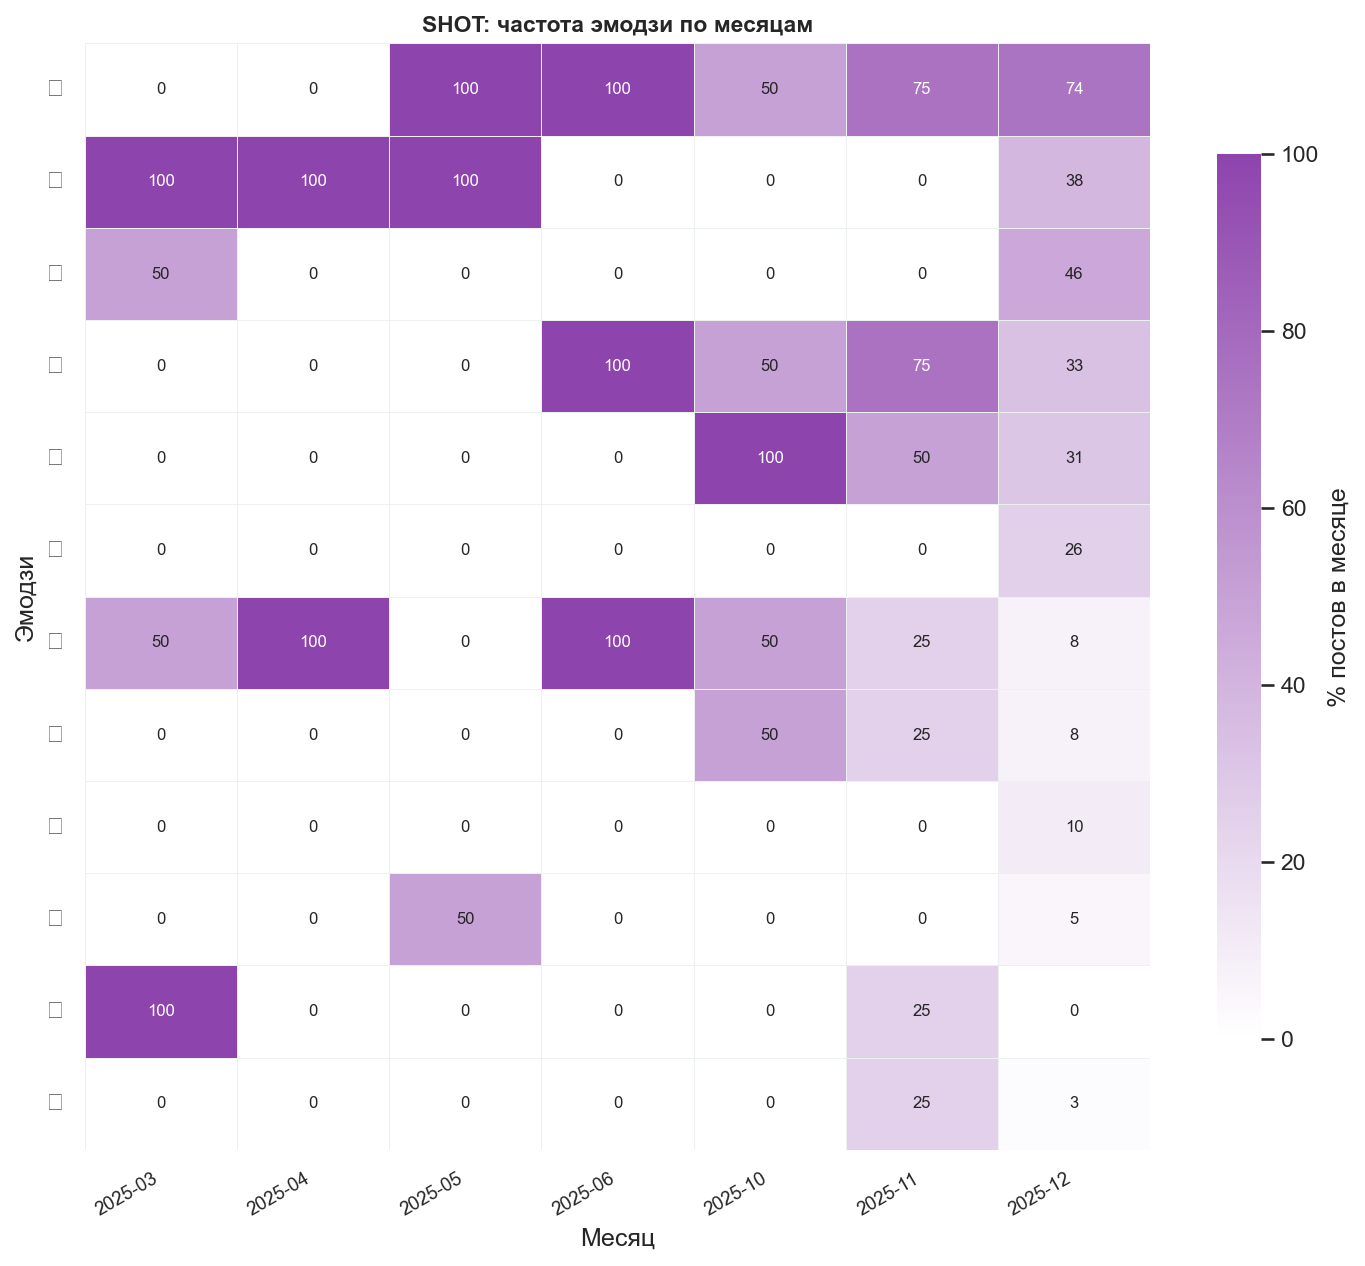

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_AlexCarrier.png


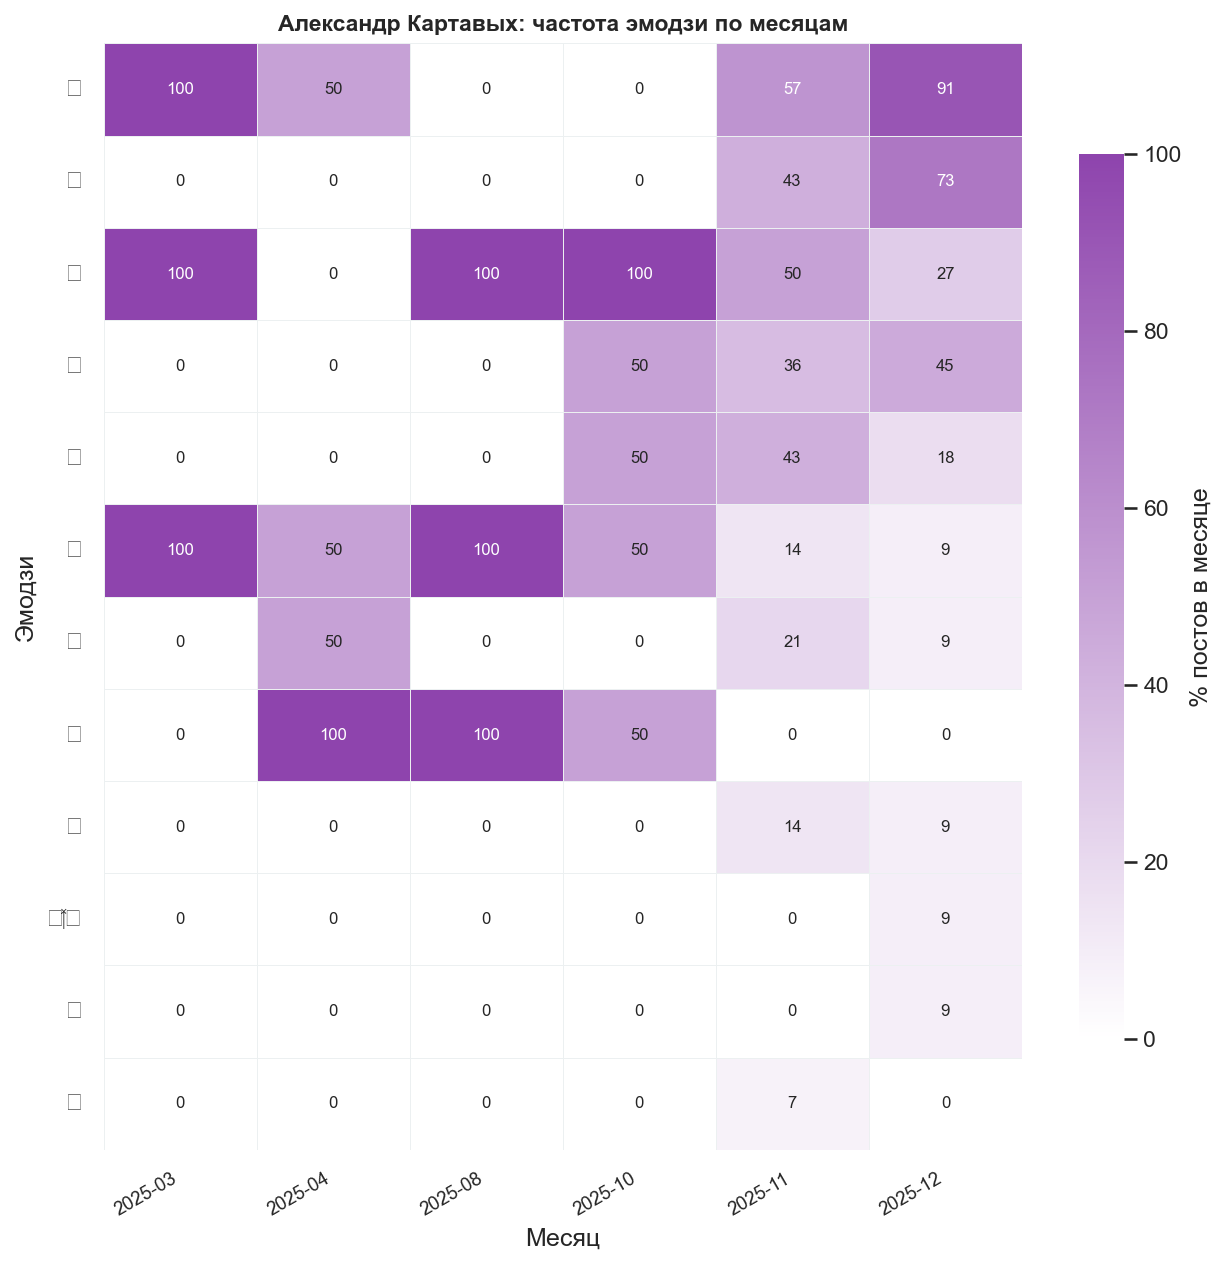

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_Cbpub.png


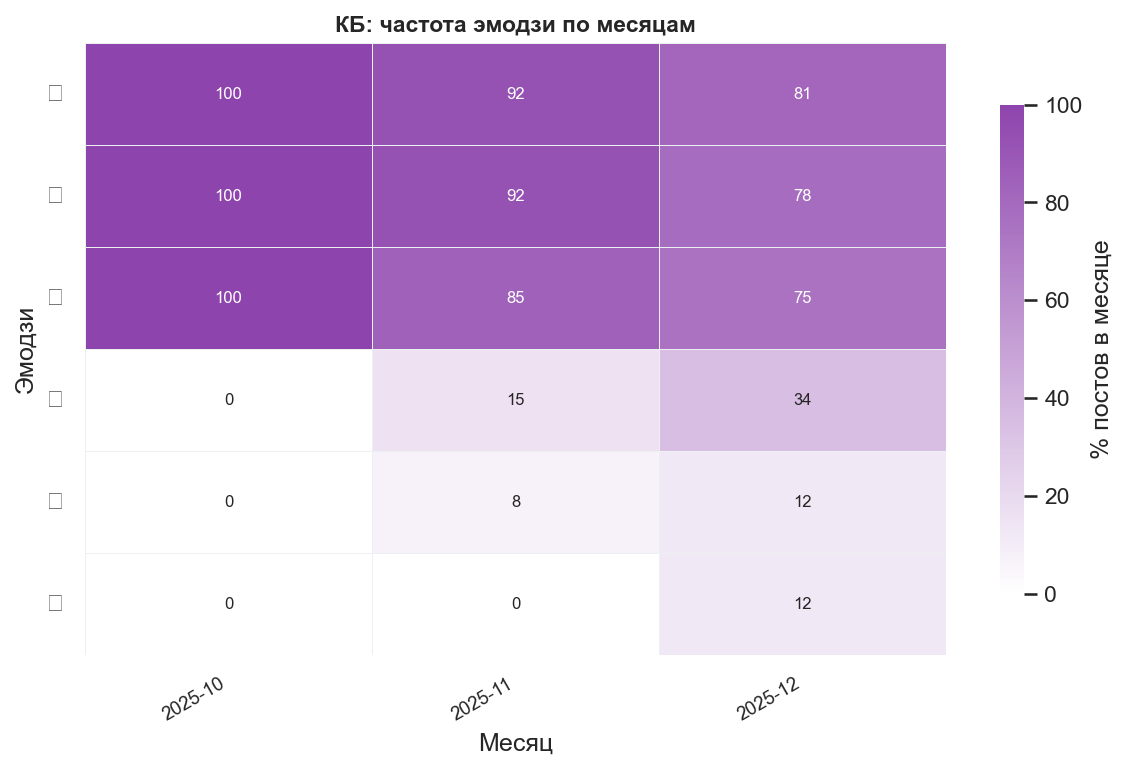

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_toporlive.png


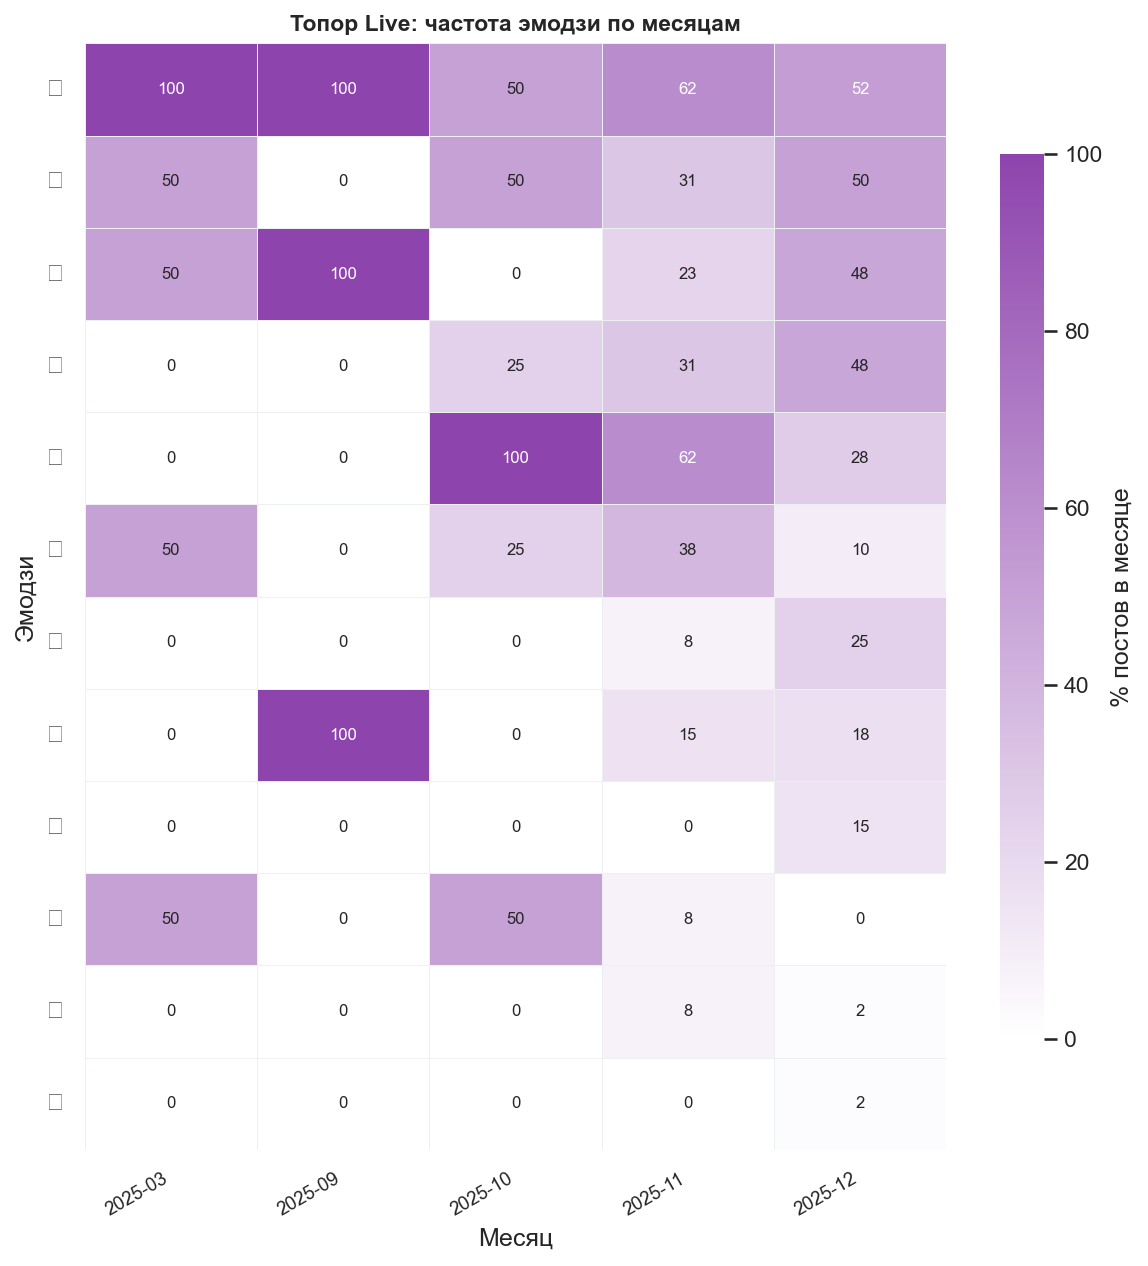

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_rian_ru.png


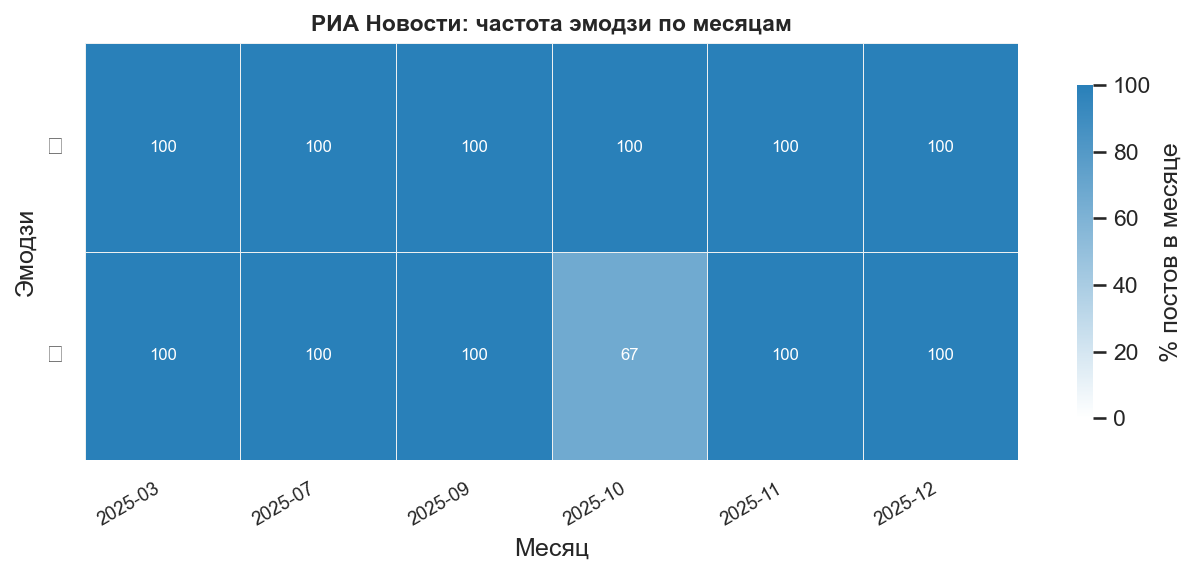

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_rbc_news.png


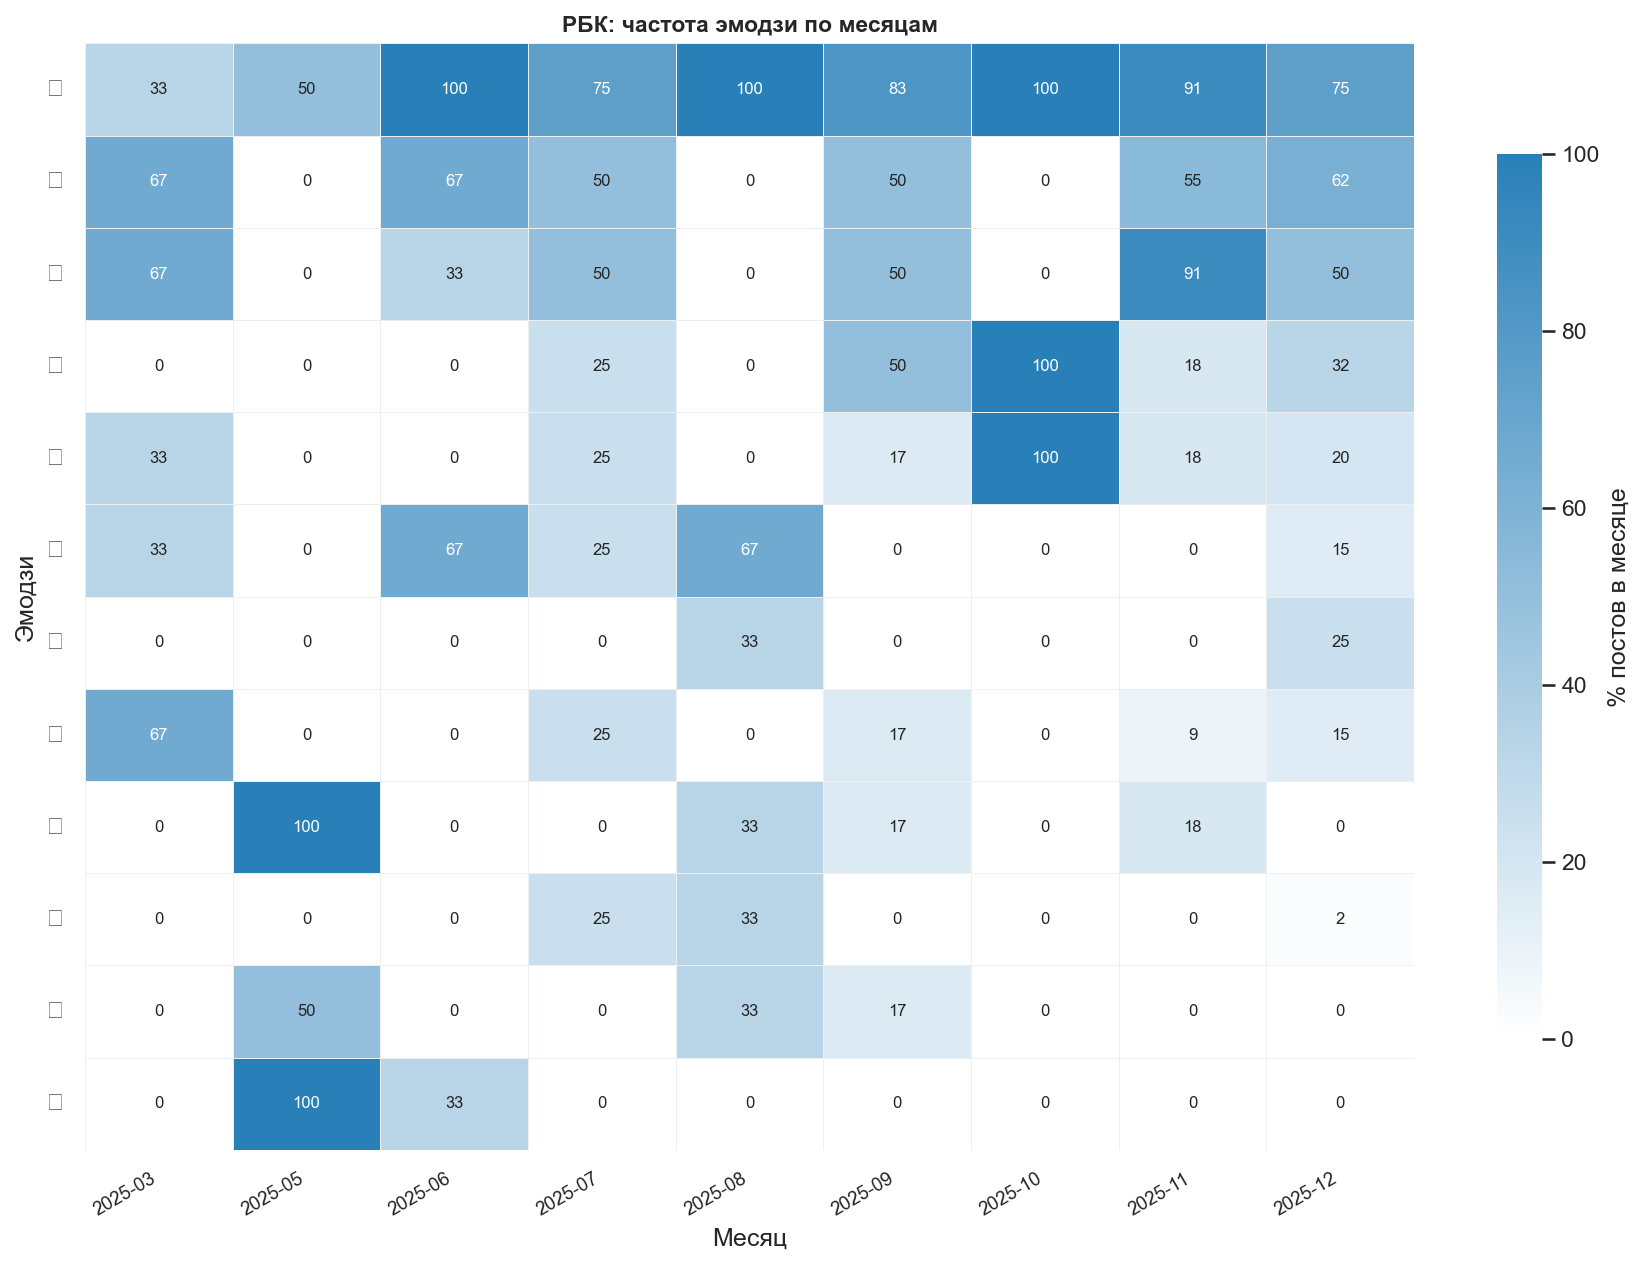

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_rt_russian.png


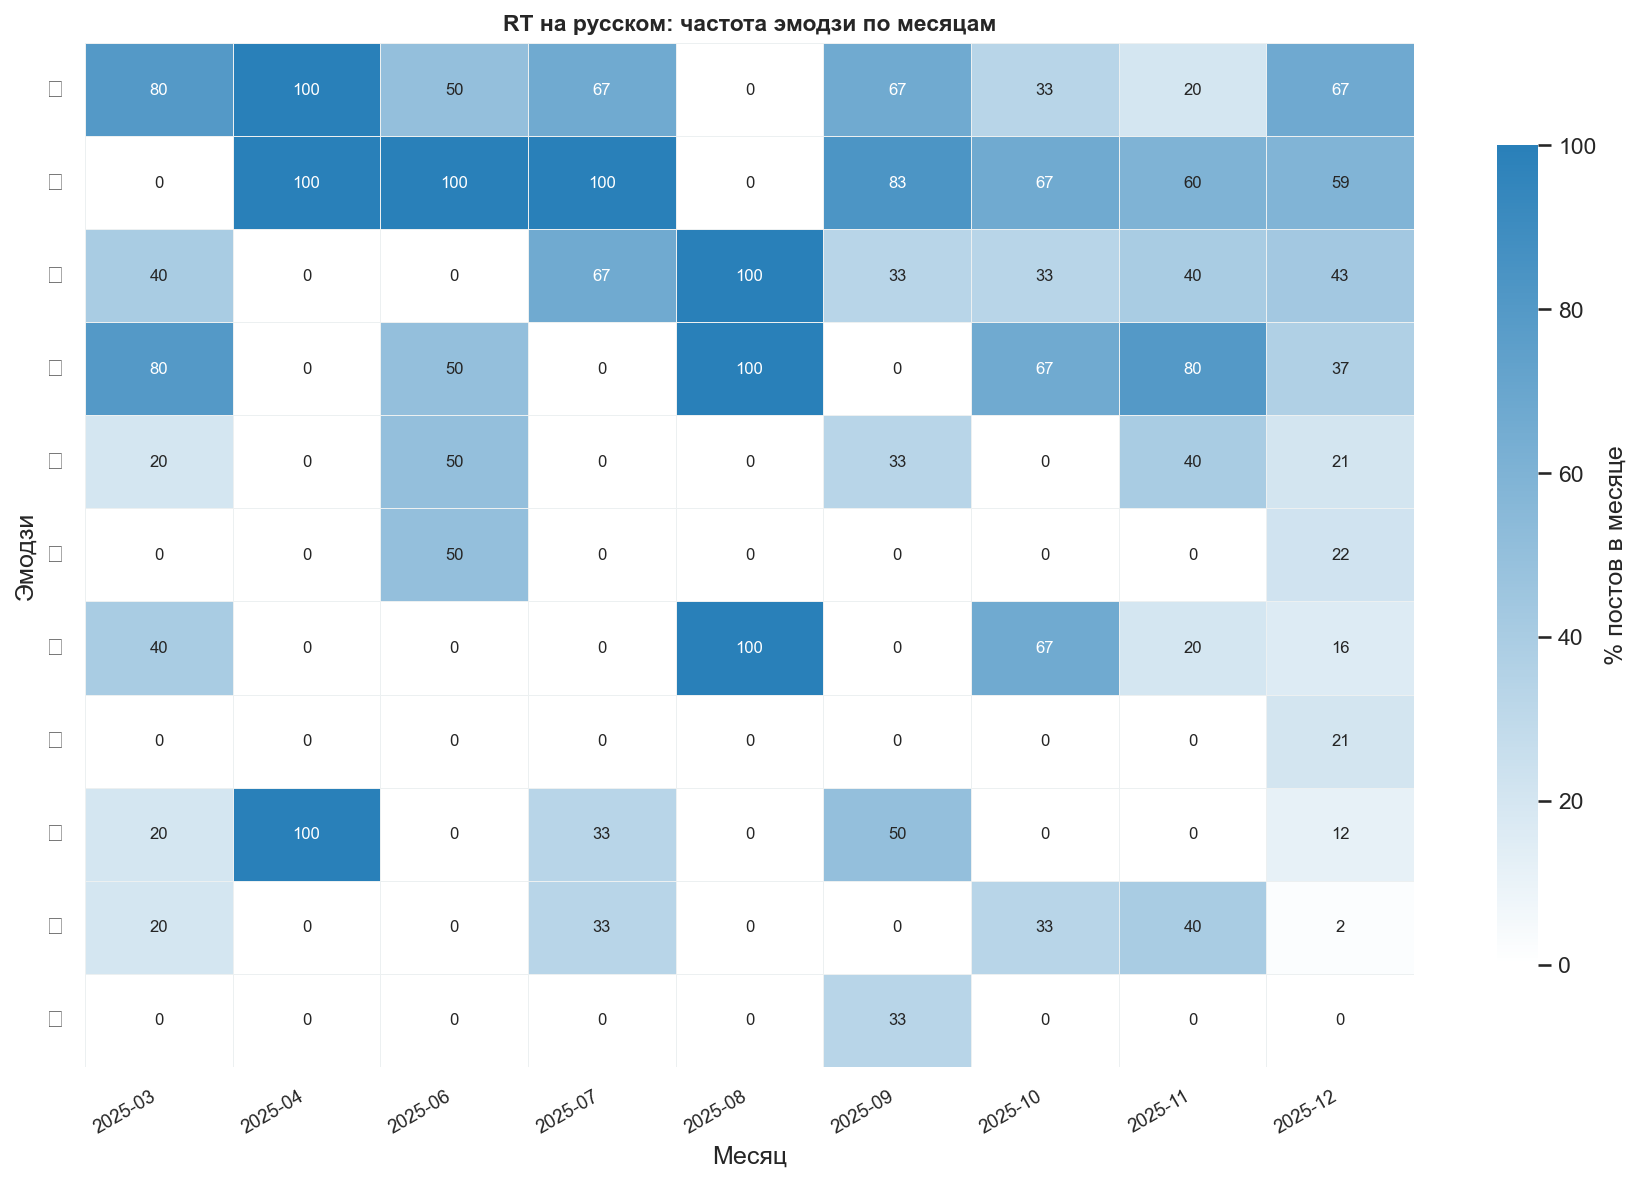

15:38:27  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_uranews.png


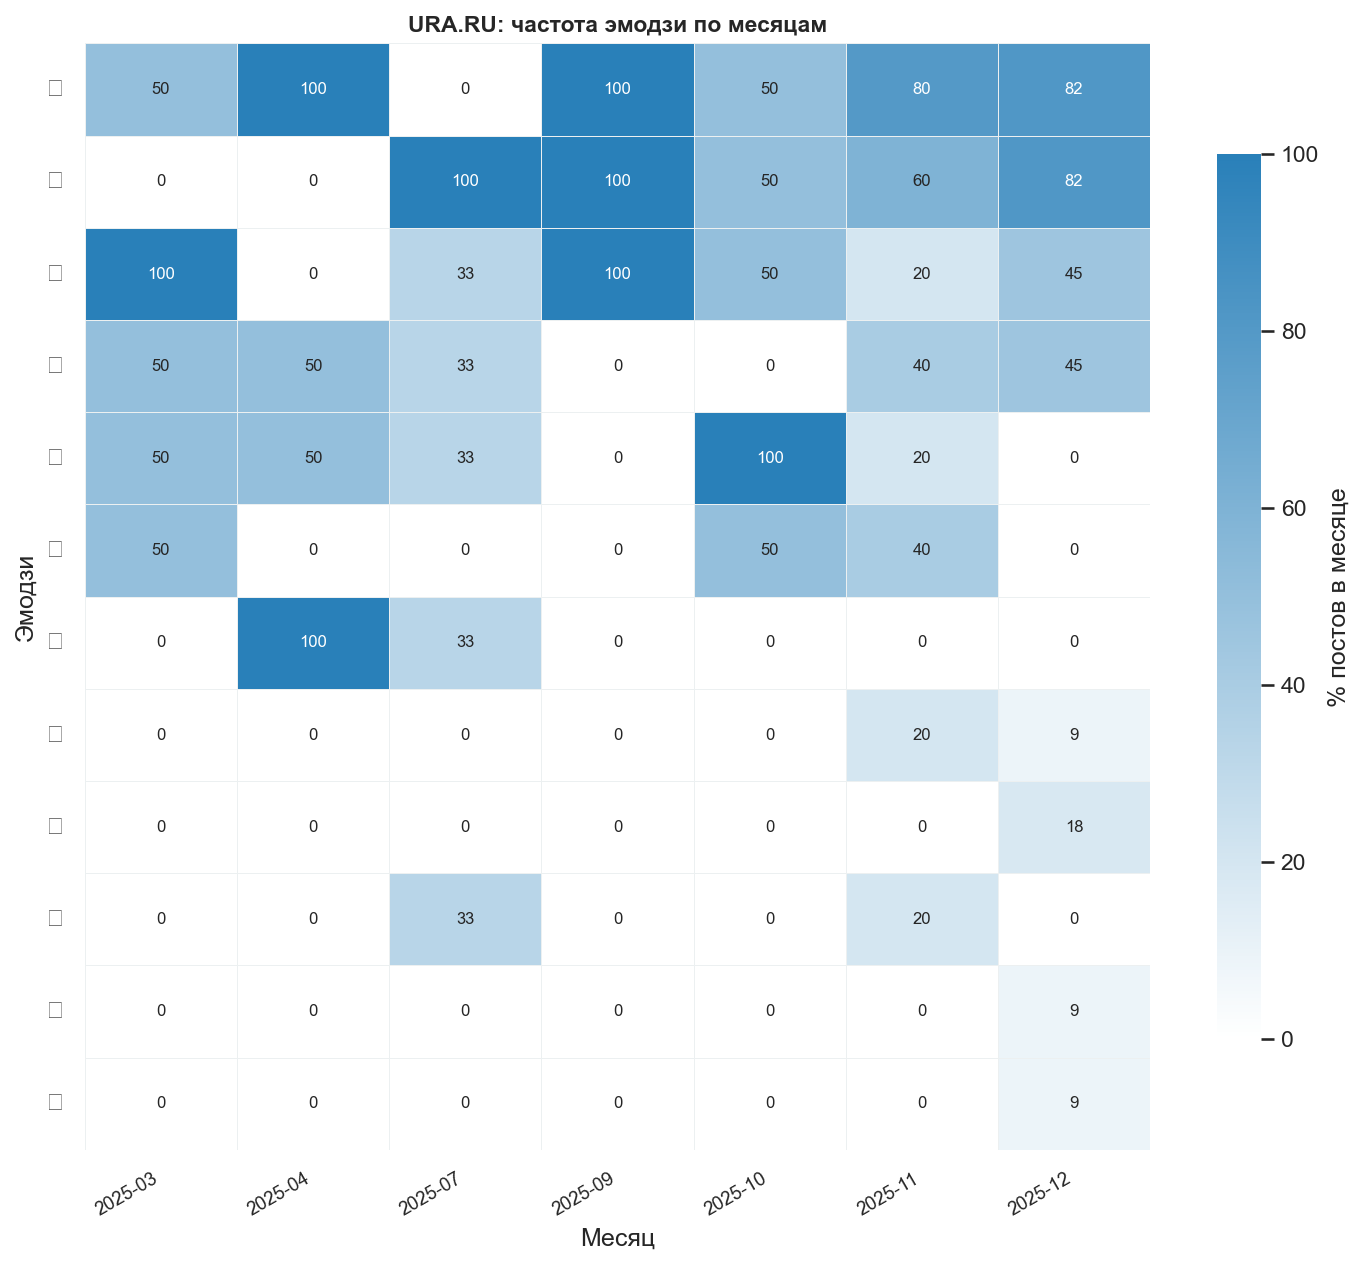

15:38:28  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_davankov.png


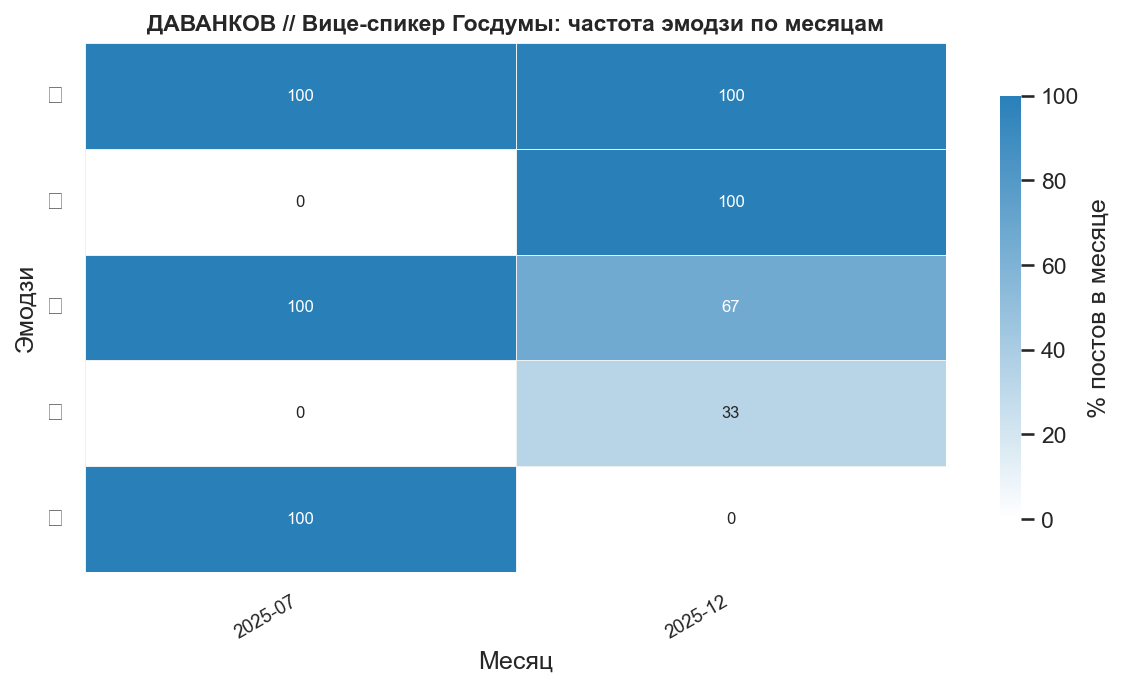

[PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_shot_shot.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_AlexCarrier.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_Cbpub.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_toporlive.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_rian_ru.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_rbc_news.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_rt_russian.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_uranews.png'),
 PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_2_monthly_davankov.png')]

In [34]:
def plot_emoji_monthly_heatmap(df: pd.DataFrame, channels: list[str] | None = None, top_n: int = 12) -> list[Path]:
    """Тепловые карты: оси X — месяцы, Y — топ-N эмодзи, значение — % постов."""
    if channels is None:
        channels = [ch["username"] for ch in CHANNELS if ch.get("reaction_type") != "none"]

    saved_paths = []
    for username in channels:
        ch_meta = next((c for c in CHANNELS if c["username"] == username), {})
        label = ch_meta.get("label", username)

        ch_df = df[
            (df["channel_username"] == username) &
            (df["reactions_top"].str.strip() != "")
        ].copy()

        if ch_df.empty:
            log.info("@%s: нет данных о реакциях, пропускаем.", username)
            continue

        counter = _count_emojis_for_df(df, username)
        top_emojis = [em for em, _ in counter.most_common(top_n)]
        if not top_emojis:
            continue

        ch_df = ch_df.dropna(subset=["date"]).copy()
        dates = ch_df["date"]
        if dates.dt.tz is not None:
            dates = dates.dt.tz_convert(None)
        ch_df["month"] = dates.dt.to_period("M").astype(str)
        months = sorted(ch_df["month"].unique())

        matrix = pd.DataFrame(index=top_emojis, columns=months, dtype=float).fillna(0.0)

        for month, month_df in ch_df.groupby("month"):
            n_month = len(month_df)
            if n_month == 0:
                continue
            for _, row in month_df.iterrows():
                emojis_in_post = str(row.get("reactions_top", "")).strip().split()
                for em in emojis_in_post:
                    if em in top_emojis:
                        matrix.at[em, month] += 1
            matrix[month] = matrix[month] / n_month * 100

        fig_h = max(4, len(top_emojis) * 0.55 + 2)
        fig_w = max(8, len(months) * 1.1 + 2)
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))

        orient = ch_meta.get("orientation", "public")
        base_color = COLOR_STATE if orient == "state" else COLOR_PUBLIC
        cmap = LinearSegmentedColormap.from_list("custom", ["#ffffff", base_color], N=256)

        sns.heatmap(
            matrix.astype(float),
            ax=ax,
            cmap=cmap,
            vmin=0, vmax=matrix.values.max() if matrix.values.max() > 0 else 1,
            linewidths=0.4,
            linecolor="#ecf0f1",
            annot=True,
            fmt=".0f",
            annot_kws={"fontsize": 8},
            cbar_kws={"label": "% постов в месяце", "shrink": 0.8},
        )

        ax.set_xlabel("Месяц")
        ax.set_ylabel("Эмодзи")
        ax.set_title(f"{label}: частота эмодзи по месяцам", fontsize=11, fontweight="bold")
        plt.xticks(rotation=30, ha="right", fontsize=9)
        plt.yticks(rotation=0, fontsize=12)

        fig.subplots_adjust(left=0.18)
        fig.tight_layout()
        fname = f"fig_emoji_2_monthly_{username}"
        path = _save(fig, fname)
        saved_paths.append(path)
    
    return saved_paths

plot_emoji_monthly_heatmap(df)

## 3. Распределение тональности эмодзи

15:38:28  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_3_sentiment_distribution.png


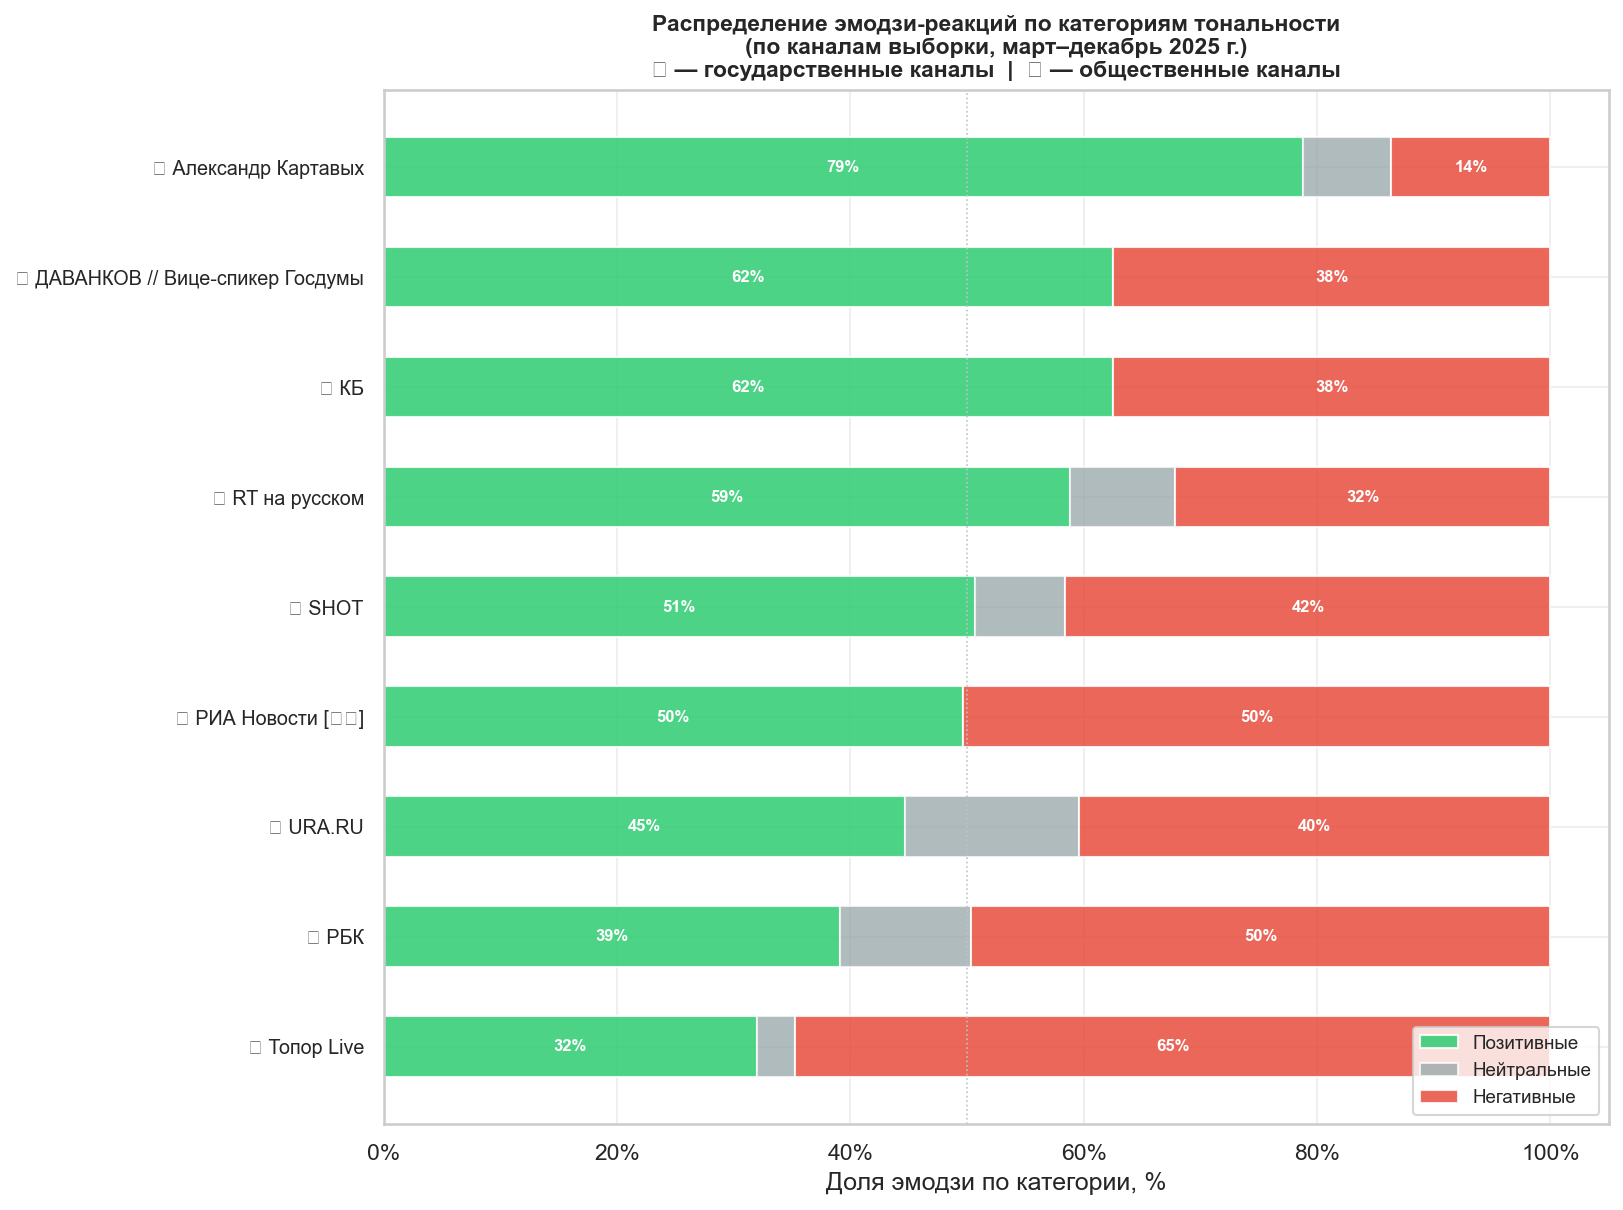

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_3_sentiment_distribution.png')

In [35]:
def plot_emoji_sentiment_distribution(df: pd.DataFrame) -> Path:
    """Stacked horizontal bar: доля позитивных/нейтральных/негативных эмодзи по каналам."""
    rows = []
    for ch in CHANNELS:
        username = ch["username"]
        rtype = ch.get("reaction_type", "none")
        if rtype == "none":
            continue

        counter = _count_emojis_for_df(df, username)
        emoji_dict = _emoji_dict_for(username)

        n_pos = n_neg = n_neu = 0
        for em, cnt in counter.items():
            cat = emoji_dict.get(em, "unknown")
            if cat == "positive":
                n_pos += cnt
            elif cat == "negative":
                n_neg += cnt
            elif cat == "neutral":
                n_neu += cnt

        total = n_pos + n_neg + n_neu
        if total == 0:
            continue

        rows.append({
            "label": ch["label"],
            "orientation": ch["orientation"],
            "rtype": rtype,
            "pct_pos": n_pos / total * 100,
            "pct_neu": n_neu / total * 100,
            "pct_neg": n_neg / total * 100,
        })

    if not rows:
        log.warning("Нет данных для plot_emoji_sentiment_distribution.")
        return FIGURES_DIR / "no_data.txt"

    df_plot = pd.DataFrame(rows).sort_values("pct_pos", ascending=True)
    fig, ax = plt.subplots(figsize=(11, max(5, len(df_plot) * 0.75 + 1.5)))

    y = range(len(df_plot))
    height = 0.55

    bars_pos = ax.barh(list(y), df_plot["pct_pos"], height=height, color=COLOR_POSITIVE, alpha=0.85, label="Позитивные")
    bars_neu = ax.barh(list(y), df_plot["pct_neu"], height=height,
                       left=df_plot["pct_pos"], color=COLOR_NEUTRAL, alpha=0.75, label="Нейтральные")
    bars_neg = ax.barh(list(y), df_plot["pct_neg"], height=height,
                       left=df_plot["pct_pos"] + df_plot["pct_neu"],
                       color=COLOR_NEGATIVE, alpha=0.85, label="Негативные")

    for bars, col in [(bars_pos, "pct_pos"), (bars_neg, "pct_neg")]:
        for bar, val in zip(bars, df_plot[col]):
            if val > 5:
                ax.text(bar.get_x() + bar.get_width() / 2,
                       bar.get_y() + bar.get_height() / 2,
                       f"{val:.0f}%", ha="center", va="center",
                       fontsize=8, color="white", fontweight="bold")

    labels_y = []
    for _, row in df_plot.iterrows():
        orient_mark = "🏛" if row["orientation"] == "state" else "📢"
        rtype_mark = " [👍👎]" if row["rtype"] == "like_dislike" else ""
        labels_y.append(f"{orient_mark} {row['label']}{rtype_mark}")

    ax.set_yticks(list(y))
    ax.set_yticklabels(labels_y, fontsize=9.5)
    ax.set_xlabel("Доля эмодзи по категории, %")
    ax.set_xlim(0, 105)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.axvline(50, color="#bdc3c7", linewidth=0.8, linestyle=":")
    ax.set_title("Распределение эмодзи-реакций по категориям тональности\n"
        "(по каналам выборки, март–декабрь 2025 г.)\n"
        "🏛 — государственные каналы  |  📢 — общественные каналы",
        fontsize=11, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9, framealpha=0.8)
    fig.tight_layout()
    return _save(fig, "fig_emoji_3_sentiment_distribution")

plot_emoji_sentiment_distribution(df)

## 4. Динамика Emoji Sentiment Index (ESI)

15:38:28  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_4_esi_timeline.png


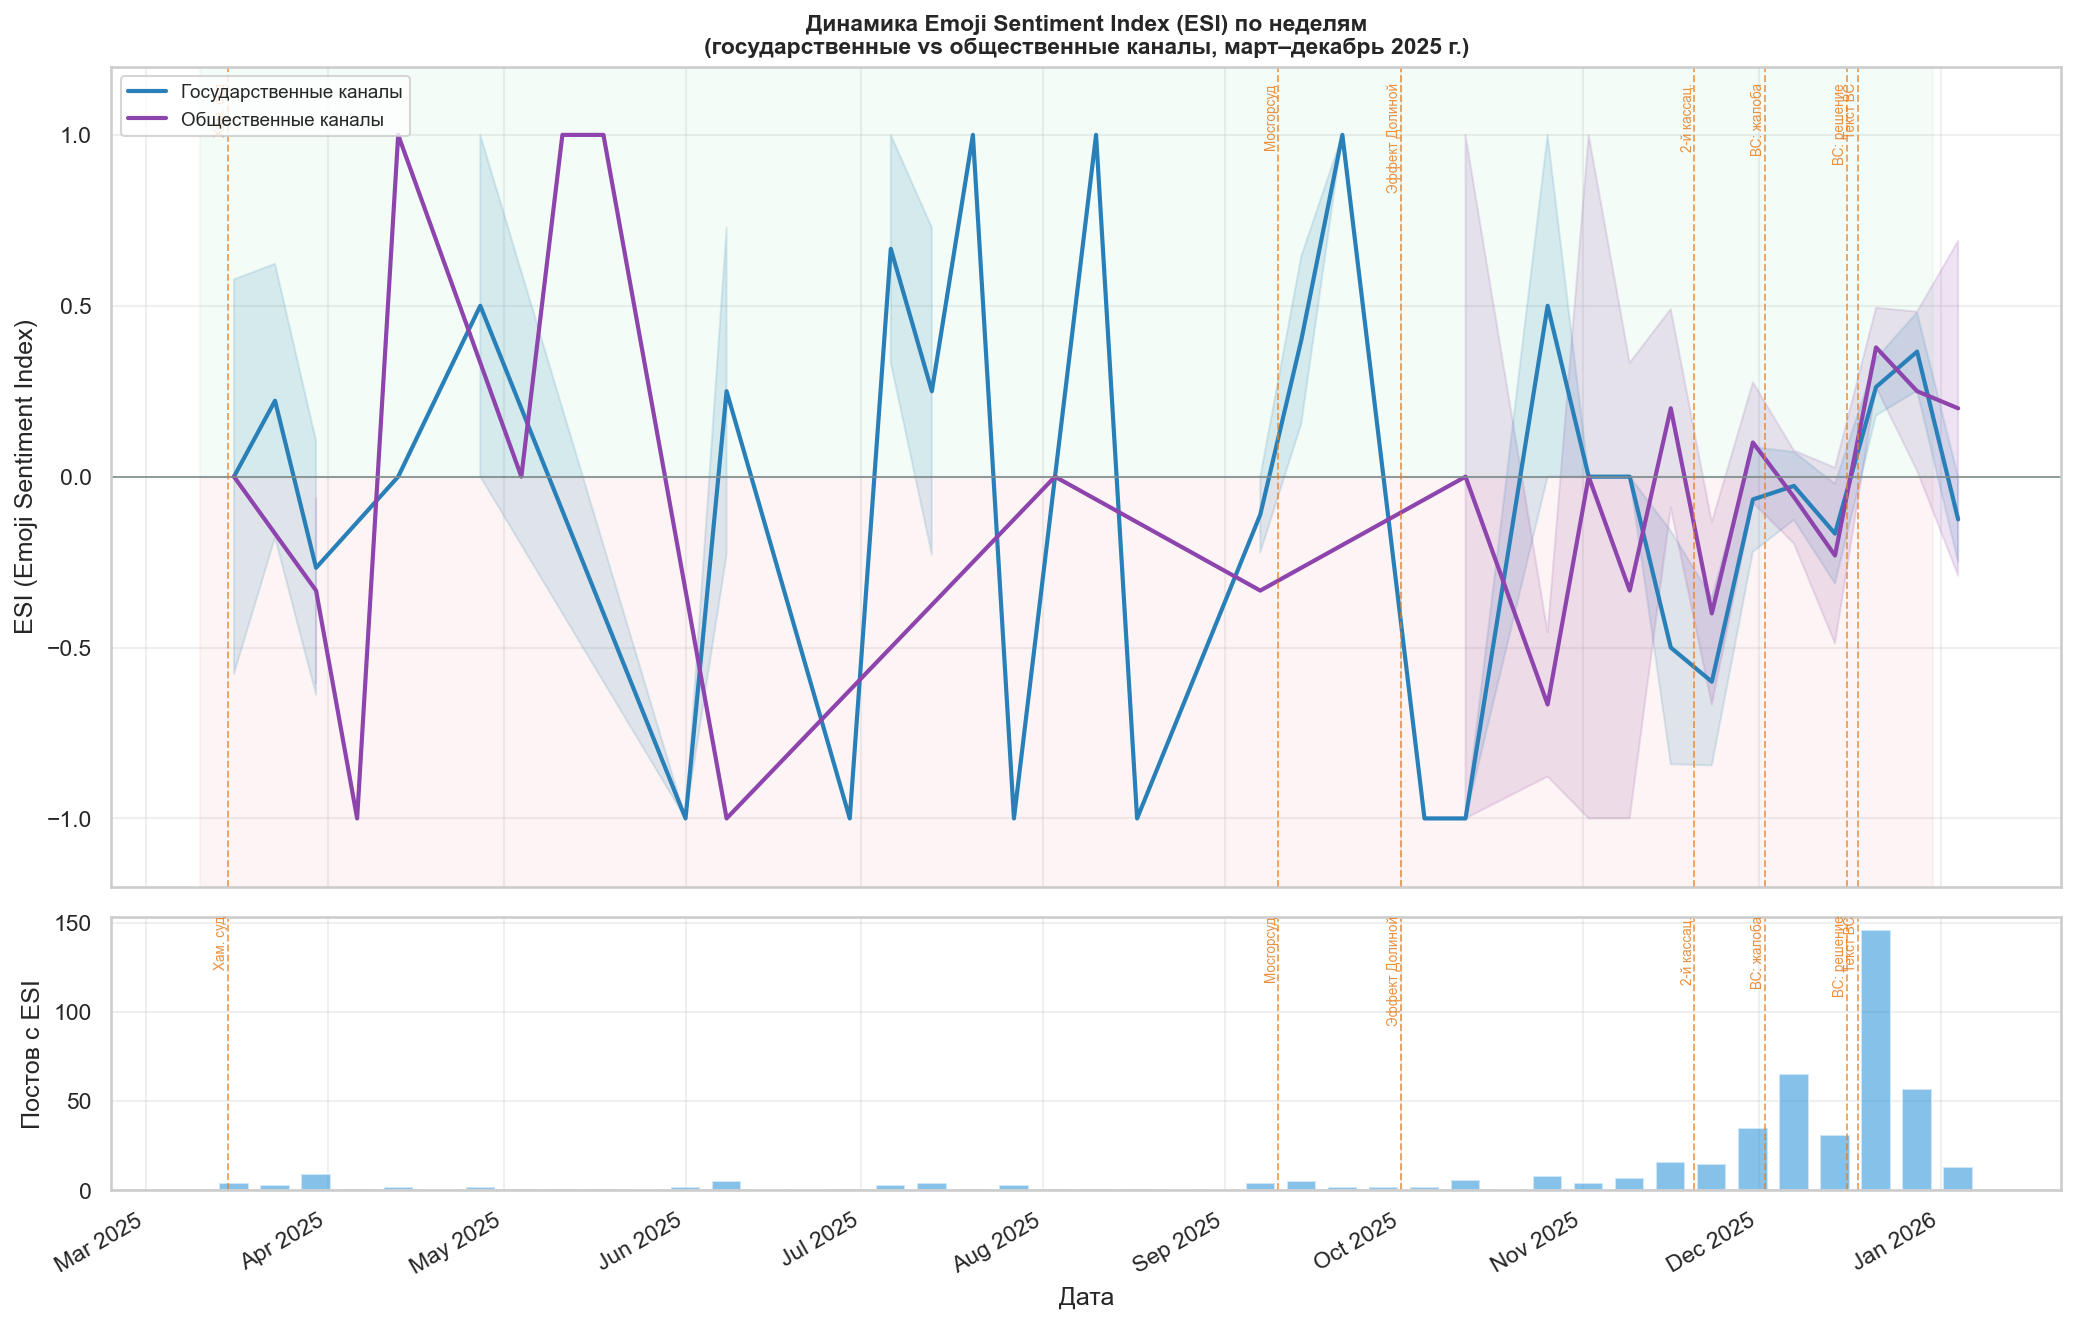

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_emoji_4_esi_timeline.png')

In [36]:
def plot_esi_timeline(df: pd.DataFrame) -> Path:
    """Динамика ESI = (n_pos − n_neg) / n_classified по неделям."""
    df2 = df.copy()
    
    # Вычисляем ESI для каждого поста
    df2["n_pos"] = 0
    df2["n_neg"] = 0
    
    for idx, row in df2.iterrows():
        if pd.isna(row["channel_username"]):
            continue
        emoji_dict = _emoji_dict_for(row["channel_username"])
        emojis = str(row.get("reactions_top", "")).strip().split()
        for em in emojis:
            cat = emoji_dict.get(em, "unknown")
            if cat == "positive":
                df2.at[idx, "n_pos"] += 1
            elif cat == "negative":
                df2.at[idx, "n_neg"] += 1
    
    df2["n_classified"] = df2["n_pos"] + df2["n_neg"]
    df2.loc[df2["n_classified"] > 0, "esi"] = (df2["n_pos"] - df2["n_neg"]) / df2["n_classified"]

    df3 = df2.dropna(subset=["date", "esi"]).copy()
    if df3.empty:
        log.warning("Нет данных ESI для построения временного ряда.")
        return FIGURES_DIR / "no_esi_data.txt"

    df3["date"] = pd.to_datetime(df3["date"], utc=True, errors="coerce")
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(14, 9), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # Верхний: ESI по ориентации
    for orient, color, lbl in [
        ("state", COLOR_STATE, "Государственные каналы"),
        ("public", COLOR_PUBLIC, "Общественные каналы"),
    ]:
        sub = df3[df3["orientation"] == orient]
        if sub.empty:
            continue
        weekly = (
            sub.set_index("date")
            .resample("W")["esi"]
            .agg(["mean", "sem"])
            .reset_index()
        )
        weekly.columns = ["period", "mean_esi", "sem_esi"]
        weekly = weekly.dropna(subset=["mean_esi"])

        ax_top.plot(weekly["period"], weekly["mean_esi"], color=color, linewidth=2.0, label=lbl)
        ax_top.fill_between(
            weekly["period"],
            weekly["mean_esi"] - weekly["sem_esi"],
            weekly["mean_esi"] + weekly["sem_esi"],
            color=color, alpha=0.15,
        )

    ax_top.axhline(0, color="#7f8c8d", linewidth=0.8, linestyle="-")
    y_abs = max(df3["esi"].abs().max() * 1.2, 0.2)
    _add_event_markers(ax_top, ymin=-y_abs, ymax=y_abs)
    ax_top.set_ylim(-y_abs, y_abs)
    ax_top.set_ylabel("ESI (Emoji Sentiment Index)")
    ax_top.set_title("Динамика Emoji Sentiment Index (ESI) по неделям\n"
        "(государственные vs общественные каналы, март–декабрь 2025 г.)",
        fontsize=11, fontweight="bold")
    ax_top.legend(loc="upper left", fontsize=9)

    ax_top.fill_between(
        [df3["date"].min(), df3["date"].max()],
        [0, 0], [y_abs, y_abs],
        color=COLOR_POSITIVE, alpha=0.05,
    )
    ax_top.fill_between(
        [df3["date"].min(), df3["date"].max()],
        [-y_abs, -y_abs], [0, 0],
        color=COLOR_NEGATIVE, alpha=0.05,
    )

    # Нижний: число постов с ESI
    weekly_all = (
        df3.set_index("date")
        .resample("W")
        .size()
        .reset_index(name="n_posts")
    )
    ax_bot.bar(
        weekly_all["date"], weekly_all["n_posts"],
        width=5, color="#3498db", alpha=0.6,
    )
    _add_event_markers(ax_bot, ymax=weekly_all["n_posts"].max() * 1.1)
    ax_bot.set_ylabel("Постов с ESI")
    ax_bot.set_xlabel("Дата")

    for ax in [ax_top, ax_bot]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())

    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    return _save(fig, "fig_emoji_4_esi_timeline")

plot_esi_timeline(df)

## Запуск всех графиков одной командой

In [37]:
def generate_all_emoji_plots() -> list[Path]:
    """Генерирует все 4 типа графиков и сохраняет в PNG."""
    saved = []

    log.info("Генерирую график 1: топ эмодзи по каналам...")
    try:
        p = plot_emoji_frequency_by_channel(df)
        saved.append(p)
    except Exception as e:
        log.error("График 1 не создан: %s", e)

    log.info("Генерирую графики 2: тепловые карты по месяцам...")
    try:
        paths = plot_emoji_monthly_heatmap(df)
        saved.extend(paths)
    except Exception as e:
        log.error("Графики 2 не созданы: %s", e)

    log.info("Генерирую график 3: распределение категорий по каналам...")
    try:
        p = plot_emoji_sentiment_distribution(df)
        saved.append(p)
    except Exception as e:
        log.error("График 3 не создан: %s", e)

    log.info("Генерирую график 4: динамика ESI...")
    try:
        p = plot_esi_timeline(df)
        saved.append(p)
    except Exception as e:
        log.error("График 4 не создан: %s", e)

    return saved

print(f"\n✓ Готово! Сохранено {len(paths)} графиков в {FIGURES_DIR}")


✓ Готово! Сохранено 12 графиков в /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures
